> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 7. Feature Selection and Dimensionality Reduction

*Scope:* Choosing which features to keep, and constructing fewer features that carry the same information.

Chapter 6 ended with a ladder where every added feature made the model worse: 0.814 down to 0.781 as the
column count doubled. This chapter is the response.

There are two distinct answers, and they are not interchangeable:

| | **Selection** | **Extraction** |
|---|---|---|
| Does | Keeps a subset of the original columns | Builds new columns from combinations of all of them |
| Output | Original features, fewer of them | New features, none of them original |
| Interpretable | Yes — "we kept tenure and tickets" | No — "component 1 is 0.4·tenure − 0.3·age + …" |
| Examples | Variance threshold, RFE, L1 | PCA, LDA, t-SNE |
| Sections | 7.2–7.4 | 7.5–7.7 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 110)
sns.set_theme(style="whitegrid")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("ready")

ready


### 7.1 The Curse of Dimensionality

As the number of features grows, the volume of the space grows exponentially while the number of samples
does not. The data becomes sparse, and several intuitions from two and three dimensions stop holding.

**Consequence 1 — everything becomes equidistant.** Distance-based methods (Chapter 14, Chapter 20) rely on
near neighbours being meaningfully nearer than far ones. In high dimensions that distinction collapses.

In [2]:
def distance_contrast(dim, n=500, seed=0):
    """Relative gap between the nearest and farthest neighbour of a random point."""
    gen = np.random.default_rng(seed)
    points = gen.uniform(size=(n, dim))
    query = gen.uniform(size=dim)
    d = np.linalg.norm(points - query, axis=1)
    return (d.max() - d.min()) / d.min()


print(f"{'dimensions':>11}   (farthest - nearest) / nearest")
for dim in (1, 2, 5, 10, 50, 200, 1000):
    print(f"{dim:>11}   {distance_contrast(dim):>10.3f}")

 dimensions   (farthest - nearest) / nearest
          1      615.806
          2       40.730
          5        6.004
         10        5.678
         50        0.622
        200        0.268
       1000        0.118


In one dimension the farthest point is hundreds of times more distant than the nearest. By 1000 dimensions
they differ by well under a factor of two — "nearest neighbour" has almost stopped meaning anything, which
is 14.7's problem stated numerically.

**Consequence 2 — the data becomes overwhelmingly sparse.** To keep the same density of samples per unit
volume, the sample size must grow exponentially with the dimension.

In [3]:
# How many samples to keep 10 per "bin" if each dimension is split into 10 intervals?
for dim in (1, 2, 3, 5, 10):
    needed = 10 * 10 ** dim
    print(f"{dim:>2}D grid of 10 intervals per axis -> {10 ** dim:>15,} cells, "
          f"{needed:>16,} samples for 10 per cell")

 1D grid of 10 intervals per axis ->              10 cells,              100 samples for 10 per cell
 2D grid of 10 intervals per axis ->             100 cells,            1,000 samples for 10 per cell
 3D grid of 10 intervals per axis ->           1,000 cells,           10,000 samples for 10 per cell
 5D grid of 10 intervals per axis ->         100,000 cells,        1,000,000 samples for 10 per cell
10D grid of 10 intervals per axis ->  10,000,000,000 cells,  100,000,000,000 samples for 10 per cell


**Consequence 3 — noise features actively hurt.** This is the mechanism behind Chapter 6's declining
ladder, and it is worth isolating: hold the real signal fixed and add columns of pure noise.

In [4]:
from sklearn.datasets import make_classification

X_signal, y_signal = make_classification(
    n_samples=300, n_features=5, n_informative=5, n_redundant=0,
    random_state=RANDOM_STATE,
)

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

print(f"{'noise columns':>14}  {'total':>6}   CV AUC")
for n_noise in (0, 5, 20, 100, 300):
    noise = rng.normal(size=(300, n_noise))
    X_aug = np.column_stack([X_signal, noise]) if n_noise else X_signal
    score = cross_val_score(pipe, X_aug, y_signal, cv=cv, scoring="roc_auc").mean()
    print(f"{n_noise:>14}  {X_aug.shape[1]:>6}   {score:.3f}")

 noise columns   total   CV AUC
             0       5   0.906
             5      10   0.897


            20      25   0.878
           100     105   0.767


           300     305   0.745


The five informative columns never change. Everything added is independent noise, containing no information
about the target by construction — and the score falls steadily anyway, because each noise column gives the
model one more coefficient with which to fit the training set's accidents.

This is the argument for the rest of the chapter in a single table.

### 7.2 Filter Methods

Filters score each feature against the target using a statistic, independently of any model. They are fast,
model-agnostic, and blind to interactions between features.

| Method | Measures | Feature type | Target type |
|---|---|---|---|
| `VarianceThreshold` | Spread (no target used) | Numeric | Any |
| Pearson / Spearman | Linear / monotonic association | Numeric | Numeric |
| `f_classif` (ANOVA F) | Between-group mean separation | Numeric | Categorical |
| `chi2` | Dependence in a contingency table | **Non-negative** | Categorical |
| `mutual_info_classif` | Any statistical dependence | Numeric | Categorical |

#### 7.2.1 Variance threshold

The only filter that ignores the target entirely. A constant column carries zero information; a
near-constant one carries almost none.

In [5]:
from sklearn.feature_selection import VarianceThreshold

demo = pd.DataFrame({
    "constant": np.ones(200),
    "almost_constant": np.r_[np.ones(198), [0, 0]],
    "binary_balanced": rng.integers(0, 2, 200),
    "continuous": rng.normal(size=200),
})

vt = VarianceThreshold(threshold=0.01).fit(demo)
print(demo.var().round(4).to_string())
print("\nkept:", list(demo.columns[vt.get_support()]))

constant           0.0000
almost_constant    0.0099
binary_balanced    0.2509
continuous         1.1235

kept: ['binary_balanced', 'continuous']


**Common mistake — applying a variance threshold to unscaled data.** Variance has units. A feature measured
in rupees has a variance millions of times larger than the same information measured in thousands of
rupees, so the threshold selects by unit rather than by informativeness.

In [6]:
scaled_units = pd.DataFrame({
    "charges_rupees": rng.normal(4000, 1500, 300),
    "charges_thousands": None,
    "satisfaction": rng.integers(1, 11, 300).astype(float),
})
scaled_units["charges_thousands"] = scaled_units["charges_rupees"] / 1000

print("variances:", scaled_units.var().round(4).to_dict())
print("\nsame information, three orders of magnitude apart in variance.")
print("kept at threshold=1.0:", list(scaled_units.columns[
    VarianceThreshold(threshold=1.0).fit(scaled_units).get_support()]))

variances:

 {'charges_rupees': 2171060.0258, 'charges_thousands': 2.1711, 'satisfaction': 8.177}

same information, three orders of magnitude apart in variance.
kept at threshold=1.0: ['charges_rupees', 'charges_thousands', 'satisfaction']


`charges_thousands` and `charges_rupees` are the same feature. One survives the threshold and one does not.
Scale first (5.5), or use a target-aware filter.

#### 7.2.2 Univariate statistical filters

In [7]:
from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif,
                                       chi2, SelectPercentile)

X_mixed, y_mixed = make_classification(
    n_samples=500, n_features=12, n_informative=4, n_redundant=2, n_repeated=0,
    shuffle=False,            # keep informative features first, so we know the truth
    random_state=RANDOM_STATE,
)
truth = ["informative"] * 4 + ["redundant"] * 2 + ["noise"] * 6

f_scores, _ = f_classif(X_mixed, y_mixed)
mi_scores = mutual_info_classif(X_mixed, y_mixed, random_state=RANDOM_STATE)

comparison = pd.DataFrame({
    "truth": truth,
    "anova_F": f_scores.round(1),
    "mutual_info": mi_scores.round(4),
}, index=[f"f{i}" for i in range(12)])
print(comparison)

           truth  anova_F  mutual_info
f0   informative     53.5       0.0761
f1   informative      0.0       0.0225
f2   informative     51.0       0.0448
f3   informative      0.8       0.0319
f4     redundant      1.5       0.0710
f5     redundant     33.2       0.0246
f6         noise      0.0       0.0000
f7         noise      1.1       0.0000
f8         noise      4.3       0.0017
f9         noise      0.1       0.0071
f10        noise      0.4       0.0000
f11        noise      0.1       0.0000


Because `shuffle=False` fixed the truth, this can be checked rather than assumed — and the check is
unflattering to the ANOVA F test.

**`f1` and `f3` are informative and score 0.0 and 0.8** on ANOVA F, below the noise feature `f8` at 4.3.
That is not a bug. `make_classification` places the informative features on a randomly rotated hypercube,
so an individual informative column can carry almost no signal *on its own* while mattering a great deal in
combination — precisely the situation 7.2.3 is about. The F test measures a single feature's ability to
separate the classes by itself, and answers that question correctly.

Mutual information does better here, because it does not assume the relationship is a difference of group
means. Take the top six by each and compare against the truth:

In [8]:
top_f = np.argsort(f_scores)[::-1][:6]
top_mi = np.argsort(mi_scores)[::-1][:6]

print("top 6 by ANOVA F     :", [f"f{i}" for i in sorted(top_f)])
print("   their true nature :", [truth[i] for i in sorted(top_f)])
print("\ntop 6 by mutual info :", [f"f{i}" for i in sorted(top_mi)])
print("   their true nature :", [truth[i] for i in sorted(top_mi)])

top 6 by ANOVA F     : ['f0', 'f2', 'f4', 'f5', 'f7', 'f8']
   their true nature : ['informative', 'informative', 'redundant', 'redundant', 'noise', 'noise']

top 6 by mutual info : ['f0', 'f1', 'f2', 'f3', 'f4', 'f5']
   their true nature : ['informative', 'informative', 'informative', 'informative', 'redundant', 'redundant']


Mutual information recovers **exactly** the four informative and two redundant columns and zero noise
columns. ANOVA F admits two noise features and discards two informative ones.

That is a genuine argument for preferring `mutual_info_classif` as a default filter, at the cost of being
slower and stochastic (it estimates from nearest-neighbour distances, hence `random_state`).

Note also that the *redundant* features score highly under both. They are linear combinations of the
informative ones, so they genuinely do predict the target — no univariate filter can notice that they add
nothing **new**. Removing redundancy needs 7.4's embedded methods or 7.5's extraction.

In [9]:
selector = SelectKBest(score_func=f_classif, k=6).fit(X_mixed, y_mixed)
print("SelectKBest(f_classif, k=6) keeps:", [f"f{i}" for i in np.flatnonzero(selector.get_support())])
print("which are                       :", [truth[i] for i in np.flatnonzero(selector.get_support())])

SelectKBest(f_classif, k=6) keeps: ['f0', 'f2', 'f4', 'f5', 'f7', 'f8']
which are                       : ['informative', 'informative', 'redundant', 'redundant', 'noise', 'noise']


**`chi2` requires non-negative features** — it is a test on a contingency table of counts, so negative
values are meaningless. This is the most common error with `SelectKBest`.

In [10]:
try:
    chi2(X_mixed, y_mixed)      # standardized data contains negatives
except ValueError as e:
    print("chi2 ->", str(e)[:70])

from sklearn.preprocessing import MinMaxScaler
chi_scores, _ = chi2(MinMaxScaler().fit_transform(X_mixed), y_mixed)
print("after MinMax scaling, top 4 by chi2:",
      [f"f{i}" for i in np.argsort(chi_scores)[::-1][:4]])

chi2 -> Input X must be non-negative.
after MinMax scaling, top 4 by chi2: ['f0', 'f2', 'f5', 'f8']


#### 7.2.3 The blind spot: filters cannot see interactions

A univariate filter scores each feature *alone*. A feature that is useless alone and decisive in
combination scores zero — which is exactly the XOR case from 6.1.

In [11]:
n = 600
x1 = rng.uniform(0, 10, n)
x2 = rng.uniform(0, 10, n)
x3 = rng.normal(size=n)                       # pure noise
y_int = ((x1 > 5) ^ (x2 > 5)).astype(int)     # depends on x1 AND x2, on neither alone

X_int = np.column_stack([x1, x2, x3])
f_int, _ = f_classif(X_int, y_int)
mi_int = mutual_info_classif(X_int, y_int, random_state=RANDOM_STATE)

print(pd.DataFrame({"anova_F": f_int.round(3), "mutual_info": mi_int.round(4)},
                   index=["x1 (needed)", "x2 (needed)", "x3 (noise)"]))

             anova_F  mutual_info
x1 (needed)    0.007       0.0000
x2 (needed)    2.521       0.0273
x3 (noise)     2.450       0.0261


`x1` and `x2` together determine the target **exactly** — knowing both gives the answer with certainty. Yet
`x1` scores *lowest of all three* on both filters, below the pure-noise column, and `x2` is
indistinguishable from noise. Ranked by either filter, the correct answer is to keep the noise feature and
discard one of the two that solve the problem.

This is not a flaw to be patched. It is the definition of a univariate method: it asks "how well does this
column predict the target alone?", and for both columns the honest answer is "not at all". It is why
wrapper and embedded methods exist.

### 7.3 Wrapper Methods

Wrappers evaluate subsets by **actually fitting the model** and scoring it. They see interactions, because
the model does. They cost far more, because they fit many models.

| Method | Strategy | Cost |
|---|---|---|
| `RFE` | Fit, drop the weakest feature, repeat | $O(p)$ fits |
| `RFECV` | RFE with cross-validation to choose how many to keep | $O(p \times k)$ fits |
| `SequentialFeatureSelector` (forward) | Start empty, add the best feature each round | $O(p^2)$ fits |
| Exhaustive search | Try every subset | $O(2^p)$ — infeasible beyond ~20 features |

In [12]:
from sklearn.feature_selection import RFE, RFECV, SequentialFeatureSelector

estimator = LogisticRegression(max_iter=2000)

rfe = RFE(estimator, n_features_to_select=6).fit(StandardScaler().fit_transform(X_mixed), y_mixed)

print(pd.DataFrame({
    "truth": truth,
    "selected": rfe.support_,
    "elimination_rank": rfe.ranking_,   # 1 = kept; higher = eliminated earlier
}, index=[f"f{i}" for i in range(12)]))

           truth  selected  elimination_rank
f0   informative      True                 1
f1   informative      True                 1
f2   informative      True                 1
f3   informative      True                 1
f4     redundant     False                 6
f5     redundant      True                 1
f6         noise     False                 5
f7         noise     False                 3
f8         noise      True                 1
f9         noise     False                 4
f10        noise     False                 2
f11        noise     False                 7


`ranking_` records the order of elimination, which is more informative than the boolean: rank 1 means kept,
and larger numbers were discarded earlier. `RFECV` goes further and chooses the number to keep by
cross-validation rather than by decree.

In [13]:
rfecv = RFECV(estimator, step=1, cv=cv, scoring="roc_auc", min_features_to_select=1)
rfecv.fit(StandardScaler().fit_transform(X_mixed), y_mixed)

print("features chosen:", rfecv.n_features_)
print("kept:", [f"f{i}" for i in np.flatnonzero(rfecv.support_)])
print("truth:", [truth[i] for i in np.flatnonzero(rfecv.support_)])

features chosen: 4
kept: ['f0', 'f2', 'f3', 'f5']
truth: ['informative', 'informative', 'informative', 'redundant']


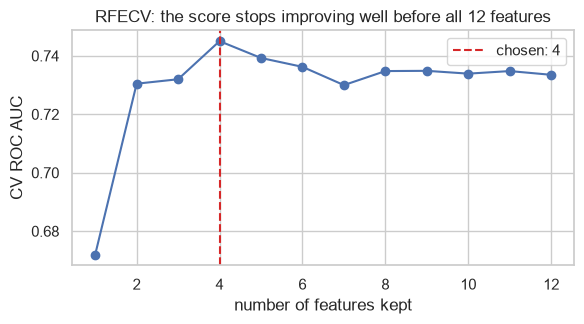

In [14]:
scores = rfecv.cv_results_["mean_test_score"]

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(range(1, len(scores) + 1), scores, "o-")
ax.axvline(rfecv.n_features_, color="tab:red", linestyle="--",
           label=f"chosen: {rfecv.n_features_}")
ax.set_xlabel("number of features kept")
ax.set_ylabel("CV ROC AUC")
ax.set_title("RFECV: the score stops improving well before all 12 features")
ax.legend()
fig.tight_layout()
plt.show()

And crucially, a wrapper solves the interaction case that defeated every filter in 7.2.3:

In [15]:
from sklearn.ensemble import RandomForestClassifier

sfs = SequentialFeatureSelector(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    n_features_to_select=2, direction="forward", cv=3, scoring="roc_auc",
).fit(X_int, y_int)

print("wrapper selected:", [["x1", "x2", "x3"][i] for i in np.flatnonzero(sfs.get_support())])
print("(the filters in 7.2.3 could not distinguish these from noise)")

wrapper selected: ['x1', 'x2']
(the filters in 7.2.3 could not distinguish these from noise)


**Common mistake — selecting features outside the cross-validation loop.** If the selector sees the whole
dataset before folds are cut, every fold's "held-out" rows already influenced which features exist. The
inflation this produces is severe, and it is easy to demonstrate on data with **no signal at all**.

In [16]:
from sklearn.model_selection import cross_val_score

X_null = rng.normal(size=(200, 2000))         # 2000 pure-noise features
y_null = rng.integers(0, 2, 200)               # a coin-flip target

# WRONG: select on all the data, then cross-validate the survivors.
best = SelectKBest(f_classif, k=10).fit(X_null, y_null)
X_leaked = best.transform(X_null)
leaked_score = cross_val_score(LogisticRegression(max_iter=2000), X_leaked, y_null,
                               cv=cv, scoring="roc_auc").mean()

# RIGHT: selection inside the pipeline, so it is refitted on each training fold.
honest_pipe = make_pipeline(SelectKBest(f_classif, k=10), LogisticRegression(max_iter=2000))
honest_score = cross_val_score(honest_pipe, X_null, y_null, cv=cv, scoring="roc_auc").mean()

print(f"select first, then CV : {leaked_score:.3f}   <- on data with NO signal")
print(f"select inside the CV  : {honest_score:.3f}   <- the truth")

select first, then CV : 0.793   <- on data with NO signal
select inside the CV  : 0.469   <- the truth


The target is a coin flip and every feature is noise, so the honest answer is 0.5. Selecting first
manufactures a large apparent signal: with 2000 random columns, some are bound to correlate with the
target by chance, and choosing them using *all* the data means the validation rows helped pick them.

This is one of the most consequential mistakes in this material. It is invisible, it survives peer review,
and the resulting model performs at chance in production. The defence is structural, as always: **the
selector goes inside the `Pipeline`** (23.2).

### 7.4 Embedded Methods

Embedded methods select as a side effect of fitting. They cost roughly one model fit, and they see
interactions to whatever extent the model does.

| Method | Mechanism | Chapter |
|---|---|---|
| L1 (lasso) penalty | Drives coefficients to exactly zero | 12.3, 12.4 |
| Tree feature importance | Total impurity reduction per feature | 17.8 |
| Permutation importance | Score drop when a feature is shuffled | 18.8, 24.3 |

In [17]:
from sklearn.feature_selection import SelectFromModel

l1_model = LogisticRegression(l1_ratio=1, solver="liblinear", C=0.1, random_state=RANDOM_STATE)
l1_model.fit(StandardScaler().fit_transform(X_mixed), y_mixed)

coefs = pd.DataFrame({"truth": truth, "coefficient": l1_model.coef_[0].round(4)},
                     index=[f"f{i}" for i in range(12)])
print(coefs)
print(f"\ncoefficients driven to exactly zero: {(l1_model.coef_[0] == 0).sum()} of 12")

           truth  coefficient
f0   informative       0.2491
f1   informative       0.0000
f2   informative       0.5333
f3   informative       0.2452
f4     redundant       0.0000
f5     redundant      -0.4417
f6         noise       0.0000
f7         noise       0.0079
f8         noise      -0.0874
f9         noise       0.0000
f10        noise      -0.0165
f11        noise       0.0000

coefficients driven to exactly zero: 5 of 12


Exact zeros, not merely small values — that is what makes L1 a *selector* rather than a shrinker, and 12.4
explains the geometry that causes it. `SelectFromModel` wraps any fitted estimator that exposes
`coef_` or `feature_importances_`:

In [18]:
from sklearn.ensemble import RandomForestClassifier

sfm_l1 = SelectFromModel(l1_model, prefit=True)
forest = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_mixed, y_mixed)
sfm_tree = SelectFromModel(forest, prefit=True, threshold="median")

print("L1 keeps  :", [f"f{i}" for i in np.flatnonzero(sfm_l1.get_support())])
print("tree keeps:", [f"f{i}" for i in np.flatnonzero(sfm_tree.get_support())])
print("\nforest importances:")
print(pd.Series(forest.feature_importances_.round(4),
                index=[f"f{i}" for i in range(12)]).sort_values(ascending=False).head(6).to_string())

L1 keeps  : ['f0', 'f2', 'f3', 'f5', 'f7', 'f8', 'f10']
tree keeps: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5']

forest importances:
f2    0.1535
f0    0.1431
f1    0.1391
f3    0.1191
f4    0.1021
f5    0.0912


### 7.5 Principal Component Analysis

PCA is **extraction**, not selection: it discards none of the original columns and instead builds new ones.
Each new feature — a **principal component** — is a linear combination of all the originals, chosen so that

1. the first component captures the most variance possible,
2. each subsequent one captures the most remaining variance while being **orthogonal** to all the earlier
   ones (2.1.2).

2.5.1 already showed the mechanism: the components are the eigenvectors of the covariance matrix, and the
eigenvalues are the variance along each.

#### 7.5.1 From scratch

In [19]:
from sklearn.datasets import load_wine

wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)   # PCA REQUIRES scaling - see 7.5.3
y_wine = wine.target

# 1. centre (already done by StandardScaler), 2. covariance, 3. eigendecompose
cov = np.cov(X_wine, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

order = np.argsort(eigenvalues)[::-1]                # largest variance first
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

explained = eigenvalues / eigenvalues.sum()
print("variance explained by the first 5 components:", explained[:5].round(4))
print("cumulative:", np.cumsum(explained)[:5].round(4))

variance explained by the first 5 components: [0.362  0.1921 0.1112 0.0707 0.0656]
cumulative: [0.362  0.5541 0.6653 0.736  0.8016]


In [20]:
# 4. project the data onto the leading components
X_manual = X_wine @ eigenvectors[:, :2]

from sklearn.decomposition import PCA

sk_pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_sklearn = sk_pca.fit_transform(X_wine)

print("explained variance ratio - from scratch:", explained[:2].round(6))
print("explained variance ratio - sklearn     :", sk_pca.explained_variance_ratio_.round(6))
print("\nprojections match (up to a sign flip, 2.5.3):",
      np.allclose(np.abs(X_manual), np.abs(X_sklearn)))

explained variance ratio - from scratch: [0.361988 0.192075]
explained variance ratio - sklearn     : [0.361988 0.192075]

projections match (up to a sign flip, 2.5.3): True


The sign caveat is 2.5.3's: an eigenvector and its negation are equally valid, so the two implementations
may place the same structure mirrored. Comparing absolute values is the correct check.

#### 7.5.2 Choosing the number of components

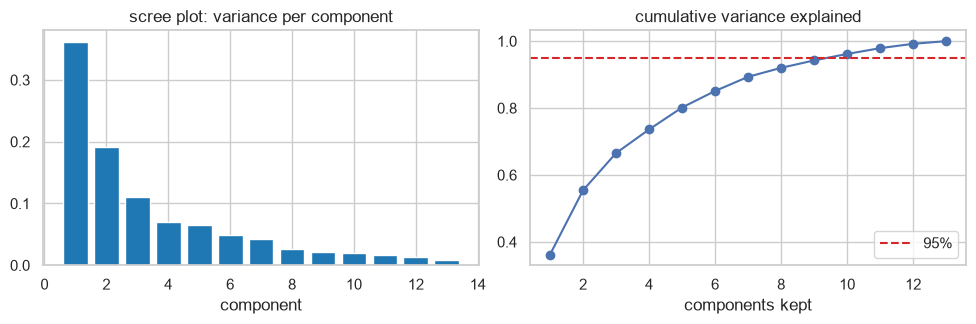

80% of variance needs  5 of 13 components
90% of variance needs  8 of 13 components
95% of variance needs 10 of 13 components
99% of variance needs 12 of 13 components


In [21]:
full_pca = PCA(random_state=RANDOM_STATE).fit(X_wine)
cumulative = np.cumsum(full_pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].bar(range(1, len(full_pca.explained_variance_ratio_) + 1),
            full_pca.explained_variance_ratio_, color="tab:blue")
axes[0].set_title("scree plot: variance per component")
axes[0].set_xlabel("component")

axes[1].plot(range(1, len(cumulative) + 1), cumulative, "o-")
axes[1].axhline(0.95, color="tab:red", linestyle="--", label="95%")
axes[1].set_title("cumulative variance explained")
axes[1].set_xlabel("components kept")
axes[1].legend()

fig.tight_layout()
plt.show()

for target in (0.80, 0.90, 0.95, 0.99):
    print(f"{target:.0%} of variance needs {np.searchsorted(cumulative, target) + 1:>2} of "
          f"{X_wine.shape[1]} components")

`n_components` accepts a float, in which case it is read as a target proportion of variance rather than a
count:

In [22]:
auto = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(X_wine)
print("components chosen for 95% variance:", auto.n_components_)
print("actual variance retained:", auto.explained_variance_ratio_.sum().round(4))

components chosen for 95% variance: 10
actual variance retained: 0.9617


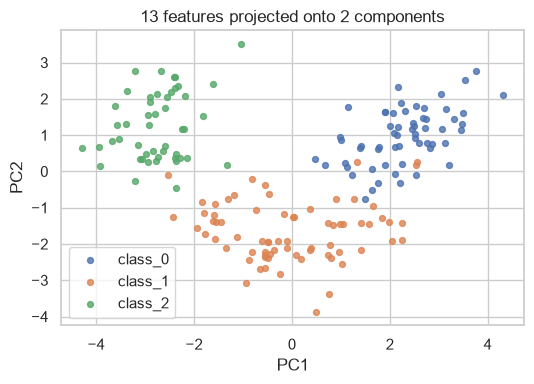

In [23]:
fig, ax = plt.subplots(figsize=(5.5, 4))
proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_wine)
for cls, name in enumerate(wine.target_names):
    m = y_wine == cls
    ax.scatter(proj[m, 0], proj[m, 1], s=18, alpha=0.8, label=name)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("13 features projected onto 2 components")
ax.legend()
fig.tight_layout()
plt.show()

Three classes are nearly separable in two dimensions built from thirteen — and PCA never saw the labels.
That is worth emphasizing: **PCA is unsupervised.** It maximizes variance, and variance is not the same
thing as class separation. When they coincide, as here, PCA looks like magic; when they do not, it can
discard exactly the direction that mattered.

In [24]:
# A deliberately adversarial case: huge variance in an irrelevant direction,
# and the class difference living in a low-variance one.
n = 400
noise_axis = rng.normal(0, 50, n)                  # enormous variance, no signal
signal_axis = np.r_[rng.normal(-1, 0.5, n // 2), rng.normal(1, 0.5, n // 2)]
y_adv = np.r_[np.zeros(n // 2), np.ones(n // 2)]

X_adv = np.column_stack([noise_axis, signal_axis])

pca_1 = PCA(n_components=1, random_state=RANDOM_STATE).fit(X_adv)
print("variance explained by PC1:", pca_1.explained_variance_ratio_[0].round(4))
print("PC1 loadings (noise, signal):", pca_1.components_[0].round(3))

auc_pc1 = cross_val_score(LogisticRegression(), pca_1.transform(X_adv), y_adv,
                          cv=cv, scoring="roc_auc").mean()
auc_raw = cross_val_score(LogisticRegression(), X_adv, y_adv, cv=cv, scoring="roc_auc").mean()
print(f"\nCV AUC using PC1 only : {auc_pc1:.3f}")
print(f"CV AUC using both raw : {auc_raw:.3f}")

variance explained by PC1: 0.9995
PC1 loadings (noise, signal): [ 1. -0.]

CV AUC using PC1 only : 0.443
CV AUC using both raw : 0.998


PC1 captures over 99% of the variance and is almost entirely the noise axis. Reducing to one component
throws away the only informative direction. Variance is a proxy for information, and 7.6's LDA is what to
reach for when the labels are available.

#### 7.5.3 Scaling is mandatory

PCA maximizes variance, and variance depends on units — so without scaling, whichever feature has the
largest numerical range dominates the first component regardless of its importance.

In [25]:
raw_pca = PCA(n_components=2).fit(wine.data)              # unscaled
scaled_pca = PCA(n_components=2).fit(X_wine)               # scaled

biggest_raw = wine.feature_names[np.argmax(np.abs(raw_pca.components_[0]))]
print("unscaled PC1 is dominated by:", biggest_raw)
print("  its variance in the raw data:", wine.data[:, np.argmax(np.abs(raw_pca.components_[0]))].var().round(1))
print("  |loading| on PC1:", np.abs(raw_pca.components_[0]).max().round(4))
print(f"\nunscaled: PC1 alone explains {raw_pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"scaled  : PC1 alone explains {scaled_pca.explained_variance_ratio_[0]:.1%} of variance")

unscaled PC1 is dominated by: proline
  its variance in the raw data: 98609.6
  |loading| on PC1: 0.9998

unscaled: PC1 alone explains 99.8% of variance
scaled  : PC1 alone explains 36.2% of variance


Unscaled, `proline` — measured in the hundreds — takes essentially the whole first component and PC1
explains 99.8% of the "variance", which is a statement about milligram units rather than about wine.
Scaled, the components describe real structure spread across features.

### 7.6 Linear Discriminant Analysis

LDA is PCA's supervised counterpart. Where PCA maximizes total variance, LDA maximizes **class
separation** — specifically the ratio of between-class scatter to within-class scatter.

| | PCA | LDA |
|---|---|---|
| Uses labels | No | **Yes** |
| Maximizes | Total variance | Between-class / within-class scatter |
| Max components | $p$ | $\min(p,\ n_{\text{classes}} - 1)$ |
| Also a classifier | No | Yes |
| Use for | Compression, decorrelation, visualization | Supervised dimensionality reduction |

The component limit is a real constraint: for binary classification LDA yields exactly **one** dimension.

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2).fit(X_wine, y_wine)
X_lda = lda.transform(X_wine)

print("wine has", len(wine.target_names), "classes -> LDA allows at most",
      len(wine.target_names) - 1, "components")
print("LDA explained variance ratio:", lda.explained_variance_ratio_.round(4))

wine has

 3 classes -> LDA allows at most 2 components
LDA explained variance ratio: [0.6875 0.3125]


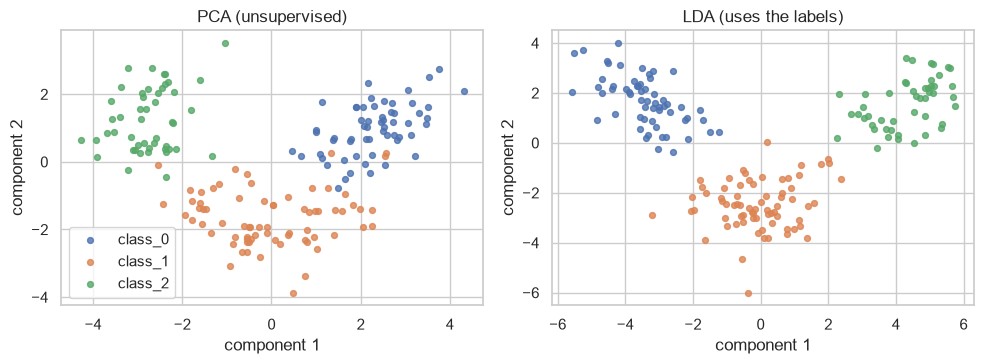

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, (data, title) in zip(axes, [(proj, "PCA (unsupervised)"), (X_lda, "LDA (uses the labels)")]):
    for cls, name in enumerate(wine.target_names):
        m = y_wine == cls
        ax.scatter(data[m, 0], data[m, 1], s=18, alpha=0.8, label=name)
    ax.set_title(title)
    ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
axes[0].legend()
fig.tight_layout()
plt.show()

LDA's separation is visibly cleaner — and it should be, because it optimized for exactly that using
information PCA never received. The catch is the same one as everywhere in this chapter: **LDA fitted on
the full dataset leaks the labels**, so it must be fitted inside the cross-validation loop like any other
learned transformation (5.1, 7.3).

Returning to 7.5.2's adversarial case, where PCA discarded the signal:

In [28]:
lda_adv = LinearDiscriminantAnalysis(n_components=1)
auc_lda = cross_val_score(make_pipeline(lda_adv, LogisticRegression()), X_adv, y_adv,
                          cv=cv, scoring="roc_auc").mean()

print(f"1 component via PCA : {auc_pc1:.3f}   (chased the high-variance noise)")
print(f"1 component via LDA : {auc_lda:.3f}   (found the class difference)")

1 component via PCA : 0.443   (chased the high-variance noise)
1 component via LDA : 0.998   (found the class difference)


### 7.7 Manifold Learning for Visualization

**t-SNE** and its relatives reduce to two or three dimensions for *looking at*, by preserving local
neighbourhood structure rather than global distances or variance.

They come with a hard restriction that is routinely violated:

| Property | PCA | t-SNE |
|---|---|---|
| Linear | Yes | No |
| Preserves | Global variance | Local neighbourhoods |
| Has a `transform()` for new data | **Yes** | **No** |
| Distances between clusters meaningful | Yes | **No** |
| Deterministic | Yes (up to sign) | No — depends on the seed |
| Safe as a modelling step | Yes | **No** |

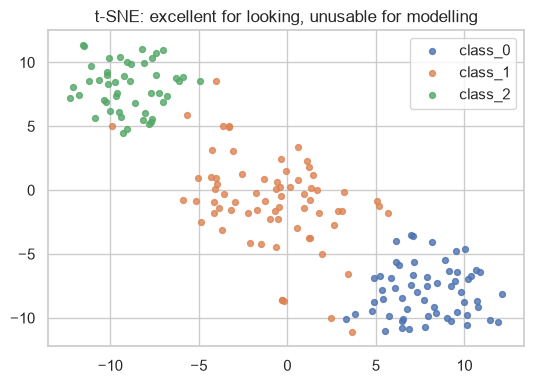

In [29]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init="pca")
X_tsne = tsne.fit_transform(X_wine)

fig, ax = plt.subplots(figsize=(5.5, 4))
for cls, name in enumerate(wine.target_names):
    m = y_wine == cls
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1], s=18, alpha=0.8, label=name)
ax.set_title("t-SNE: excellent for looking, unusable for modelling")
ax.legend()
fig.tight_layout()
plt.show()

**Why it cannot be a modelling step.** t-SNE has no `transform()` method at all — the embedding is
optimized for the specific points it was given, and there is no function to apply to a new row. A model
trained on a t-SNE embedding therefore has no way to embed anything at inference time.

In [30]:
print("PCA has transform() :", hasattr(PCA(), "transform"))
print("TSNE has transform():", hasattr(TSNE(), "transform"))

try:
    TSNE(n_components=2).fit(X_wine).transform(X_wine[:5])
except AttributeError as e:
    print("->", str(e)[:80])

PCA has transform() : True
TSNE has transform(): False


-> 'TSNE' object has no attribute 'transform'


**Common mistake — reading meaning into t-SNE's cluster sizes and distances.** The optimization preserves
*who is near whom*, not how far apart or how large anything is. Two clusters drawn far apart may be
adjacent in the original space, and a large blob is not a more variable group. The `perplexity`
hyperparameter changes the picture substantially, which is itself the warning.

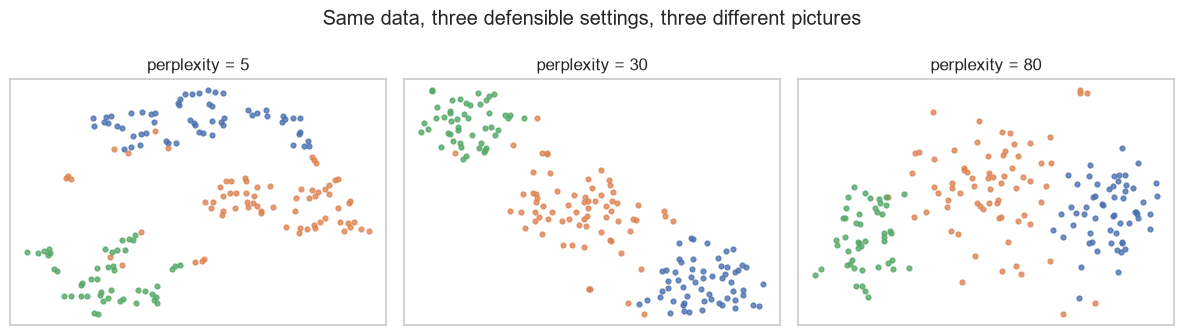

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, perp in zip(axes, (5, 30, 80)):
    emb = TSNE(n_components=2, perplexity=perp, random_state=RANDOM_STATE,
               init="pca").fit_transform(X_wine)
    for cls in range(3):
        m = y_wine == cls
        ax.scatter(emb[m, 0], emb[m, 1], s=12, alpha=0.8)
    ax.set_title(f"perplexity = {perp}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Same data, three defensible settings, three different pictures")
fig.tight_layout()
plt.show()

### 7.8 Selection versus Extraction

| Question | Answer |
|---|---|
| Must a stakeholder understand which inputs the model uses? | **Selection** — extraction destroys column identity |
| Is there a regulatory or audit requirement? | **Selection** (24.1) |
| Are features expensive to collect or compute? | **Selection** — it lets you stop collecting the rest |
| Are the features highly correlated with each other? | **Extraction** — PCA decorrelates by construction |
| Do you need to shrink hundreds of columns fast? | **Extraction** |
| Are you visualizing? | **Extraction** (7.5, 7.7) |
| Are you using a tree ensemble? | Often **neither** — they tolerate irrelevant features well |

The last row matters. Trees choose a feature per split and simply never choose useless ones, so the cost of
a noise column is far lower than for a linear model (7.1). The declining ladder of Chapter 6 was a
*logistic regression* result; a forest on the same columns degrades much more gently.

In [32]:
print(f"{'noise columns':>14}   {'logistic':>9}   {'forest':>8}")
for n_noise in (0, 20, 100, 300):
    noise = rng.normal(size=(300, n_noise))
    X_aug = np.column_stack([X_signal, noise]) if n_noise else X_signal
    lin = cross_val_score(pipe, X_aug, y_signal, cv=cv, scoring="roc_auc").mean()
    frs = cross_val_score(RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE),
                          X_aug, y_signal, cv=cv, scoring="roc_auc").mean()
    print(f"{n_noise:>14}   {lin:>9.3f}   {frs:>8.3f}")

 noise columns    logistic     forest


             0       0.906      0.937


            20       0.883      0.920


           100       0.837      0.892


           300       0.729      0.829


### 7.9 In Practice

#### 7.9.1 A worked case: repairing Chapter 6's declining ladder

Chapter 6 built seventeen features and watched cross-validated AUC fall from 0.814 to 0.781. The diagnosis
from 7.1 is that the added columns were mostly noise, and each one bought the model another coefficient to
overfit with. The treatment is selection — applied **inside** the cross-validation loop (7.3).

Rebuild the same feature set first.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}
REFERENCE_DATE = pd.Timestamp("2024-01-01")


def prepare(df):
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = out["gender"].str.strip().str.lower().replace({"male": "m", "female": "f"})
    out["signup_date"] = pd.to_datetime(out["signup_date"])
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    out["days_since_signup"] = (REFERENCE_DATE - out["signup_date"]).dt.days
    out["signup_month_sin"] = np.sin(2 * np.pi * out["signup_date"].dt.month / 12)
    out["signup_month_cos"] = np.cos(2 * np.pi * out["signup_date"].dt.month / 12)
    out["tickets_per_month"] = out["support_tickets"] / out["tenure_months"].clip(lower=1)
    out["charges_per_tenure"] = out["total_charges"] / out["tenure_months"].clip(lower=1)
    out["login_recency_ratio"] = out["last_login_days"] / out["tenure_months"].clip(lower=1)
    return out


data = prepare(pd.read_csv("data/customers.csv"))
train, test = train_test_split(data, test_size=0.2, stratify=data["churned"],
                               random_state=RANDOM_STATE)

numeric = ["age", "tenure_months", "monthly_charges", "total_charges", "support_tickets",
           "last_login_days", "satisfaction_score", "days_since_signup",
           "signup_month_sin", "signup_month_cos", "tickets_per_month",
           "charges_per_tenure", "login_recency_ratio"]
categorical = ["gender", "city", "plan"]

encoder = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), categorical),
])

X_all = train[numeric + categorical]
y_all = train["churned"]
print("encoded width:", encoder.fit_transform(X_all).shape[1], "columns")

encoded width: 26 columns


In [34]:
from sklearn.feature_selection import SelectFromModel

def bench(name, model):
    auc = cross_val_score(model, X_all, y_all, cv=cv, scoring="roc_auc").mean()
    print(f"{name:<44} CV AUC {auc:.4f}")
    return auc


baseline_lr = LogisticRegression(max_iter=3000)

bench("all features, no selection", make_pipeline(encoder, baseline_lr))
bench("SelectKBest(f_classif, k=8)", make_pipeline(encoder, SelectKBest(f_classif, k=8), baseline_lr))
bench("SelectKBest(mutual_info, k=8)",
      make_pipeline(encoder, SelectKBest(mutual_info_classif, k=8), baseline_lr))

all features, no selection                   CV AUC 0.7804


SelectKBest(f_classif, k=8)                  CV AUC 0.8039


SelectKBest(mutual_info, k=8)                CV AUC 0.8019


np.float64(0.8018930979102354)

In [35]:
bench("L1 embedded selection",
      make_pipeline(encoder,
                    SelectFromModel(LogisticRegression(l1_ratio=1, solver="liblinear",
                                                       C=0.1, random_state=RANDOM_STATE)),
                    baseline_lr))

bench("RFE to 8 features",
      make_pipeline(encoder, RFE(LogisticRegression(max_iter=2000), n_features_to_select=8),
                    baseline_lr))

bench("PCA to 8 components", make_pipeline(encoder, PCA(n_components=8, random_state=RANDOM_STATE),
                                           baseline_lr))

L1 embedded selection                        CV AUC 0.8037


RFE to 8 features                            CV AUC 0.7958


PCA to 8 components                          CV AUC 0.8061


np.float64(0.8061476395179981)

Every selector is inside the pipeline, so each is refitted on each training fold — the fold's held-out rows
never influence which features exist (7.3). That single structural detail is what separates these numbers
from the manufactured 0.7-something of the leakage demo.

Which `k` is right? Do not guess it; search it.

In [36]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(
    make_pipeline(encoder, SelectKBest(f_classif), baseline_lr),
    param_grid={"selectkbest__k": [2, 4, 6, 8, 10, 14, 18, 22]},
    cv=cv, scoring="roc_auc",
)
search.fit(X_all, y_all)

results = pd.DataFrame({
    "k": search.cv_results_["param_selectkbest__k"],
    "cv_auc": search.cv_results_["mean_test_score"].round(4),
    "std": search.cv_results_["std_test_score"].round(4),
})
print(results.to_string(index=False))
print(f"\nbest k = {search.best_params_['selectkbest__k']}, CV AUC {search.best_score_:.4f}")

 k  cv_auc    std
 2  0.7575 0.0547
 4  0.8104 0.0503
 6  0.8088 0.0488
 8  0.8039 0.0468
10  0.8007 0.0423
14  0.7921 0.0358
18  0.7903 0.0325
22  0.7858 0.0350

best k = 4, CV AUC 0.8104


In [37]:
from sklearn.metrics import roc_auc_score

final = search.best_estimator_
test_auc = roc_auc_score(test["churned"], final.predict_proba(test[numeric + categorical])[:, 1])

print(f"chosen model on the held-out TEST set: AUC {test_auc:.4f}")
print(f"features used: {search.best_params_['selectkbest__k']} of "
      f"{encoder.fit_transform(X_all).shape[1]} encoded columns")

chosen model on the held-out TEST set: AUC 0.8347
features used: 4 of 26 encoded columns


The conclusion to report is a comparison, not a single number: **a small selected subset matches or beats
the full seventeen-feature set while using a fraction of the columns**, which is cheaper to compute, easier
to explain, and less exposed to any one input drifting in production (24.9).

Note the `std` column in the search results. Several values of `k` sit within one standard deviation of
each other, which means the difference between them is not resolvable at this sample size (2.8.3). Picking
the maximum is defensible; claiming that maximum is meaningfully better than its neighbours is not, and
23.8 explains why the best search score is itself an optimistic estimate.

#### 7.9.2 When to reach for which method

| Situation | Use | Not |
|---|---|---|
| Hundreds of features, need a fast first cut | Filter (7.2) | Wrapper — too slow |
| Features interact | Wrapper (7.3) or embedded (7.4) | Univariate filters — blind to it (7.2.3) |
| Already fitting a linear model | L1 penalty (7.4) | A separate selection step |
| Already fitting a tree ensemble | Often nothing (7.8) | Aggressive selection |
| Constant or near-constant columns | `VarianceThreshold`, after scaling | Before scaling (7.2.1) |
| Highly correlated features, interpretability not needed | PCA (7.5) | Selection — it keeps arbitrary members of correlated groups |
| Need to explain the inputs | Selection | PCA — components are not explainable |
| Binary target, want supervised reduction | LDA — but it gives only 1 component | PCA, if the signal is low-variance (7.5.2) |
| Making a picture | t-SNE (7.7) | t-SNE as a model input |
| **Any of the above** | Inside a `Pipeline` | On the full dataset first (7.3) |

#### 7.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Selection outside the CV loop** | Excellent offline score, chance performance in production | 7.3 |
| **PCA fitted on train+test** | Same, quieter | 5.1 |
| **Components change on refit** | PC1 flips sign or reorders; downstream logic breaks silently | 2.5.3 |
| **A selected feature stops being collected** | The pipeline fails, or receives a constant | 24.9 |
| **Variance threshold on unscaled data** | Useful features dropped because their units are small | 7.2.1 |
| **t-SNE in a pipeline** | Cannot embed new data at all — no `transform()` | 7.7 |
| **Selection makes the model brittle** | Fewer features means more weight on each survivor | Below |

The last row is a trade worth naming explicitly. Selection concentrates the model's dependence: a model
using 8 features leans harder on each than one using 23. If a single upstream column starts arriving null,
the 8-feature model degrades much more sharply. This is not an argument against selection — it is an
argument for monitoring the features you kept (24.9), and for preferring a selection that a human can
defend over one that a search merely maximized.

In [38]:
# --- 7. Feature Selection and Dimensionality Reduction — scratch cell ---# Experiments for this chapter. Promote anything worth keeping into the# relevant section as a proper example cell.